In [4]:
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd


# Rutas y nombres de columnas configurables.
NOTEBOOK_DIR = Path.cwd()
DATA_PATH = NOTEBOOK_DIR.parent / "BaseDatos" / "BD Quindio unificados V2" / "df_filtered.csv"
RESULTS_DIR = NOTEBOOK_DIR.parent / "Resultados"
OUTPUT_FIGURE_PATH = NOTEBOOK_DIR / "cumulative_productivity_N2P2_treatments.pdf"

TREATMENT_COLUMN = "Tratamiento"
DATE_COLUMN = "Fecha"
HARVEST_WEIGHT_COLUMN = "Peso frutos cosechados (Kg)"
HARVEST_COUNT_COLUMN = "Numero frutos cosechados "
TREATMENT_PREFIX = "_N2P2"


def load_harvest_data(data_path):
    """Load the sensor and harvest dataset from the configured CSV path."""
    if not data_path.exists():
        raise FileNotFoundError(f"Dataset not found: {data_path}")

    data = pd.read_csv(data_path)
    required_columns = {
        TREATMENT_COLUMN,
        DATE_COLUMN,
        HARVEST_WEIGHT_COLUMN,
        HARVEST_COUNT_COLUMN,
    }
    missing_columns = sorted(required_columns - set(data.columns))
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")

    data[DATE_COLUMN] = pd.to_datetime(data[DATE_COLUMN], errors="coerce")
    return data


df_harvest = load_harvest_data(DATA_PATH)
print(f"Loaded {len(df_harvest):,} rows from {DATA_PATH}")

Loaded 2,262 rows from /export2/svargash/PAI-Quindio/Code/Analisis-PAI/BaseDatos/BD Quindio unificados V2/df_filtered.csv


Treatments included: T21_N2P2K0, T26_N2P2K1, T27_N2P2K2, T30_BIO N2P2K2


,Tratamiento,total_harvested_kg
2,T27_N2P2K2,31.4110
1,T26_N2P2K1,26.0038
0,T21_N2P2K0,23.8642
3,T30_BIO N2P2K2,19.6568


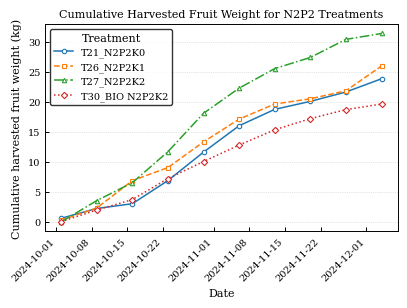

(<Figure size 400x300 with 1 Axes>,
 <Axes: title={'center': 'Cumulative Harvested Fruit Weight for N2P2 Treatments'}, xlabel='Date', ylabel='Cumulative harvested fruit weight (kg)'>)

In [7]:
def select_treatments_by_pattern(data, treatment_column, pattern):
    """Return rows whose treatment name contains the requested pattern."""
    treatment_names = data[treatment_column].astype("string")
    pattern_mask = treatment_names.str.contains(pattern, case=False, na=False, regex=False)
    selected = data.loc[pattern_mask].copy()
    if selected.empty:
        raise ValueError(f"No treatments matched the pattern: {pattern}")
    return selected


def build_daily_harvest(data, treatment_column, date_column, value_column):
    """Aggregate harvested fruit weight by treatment and day."""
    daily_data = data.dropna(subset=[treatment_column, date_column, value_column]).copy()
    daily_data[value_column] = pd.to_numeric(daily_data[value_column], errors="coerce")
    daily_data = daily_data.dropna(subset=[value_column])
    daily_data = (
        daily_data.groupby([treatment_column, date_column], as_index=False)[value_column]
        .sum()
        .sort_values([treatment_column, date_column])
    )
    if daily_data.empty:
        raise ValueError(f"No valid values found for {value_column}")
    return daily_data


def add_cumulative_harvest(data, treatment_column, date_column, value_column):
    """Add a cumulative harvested-weight column within each treatment."""
    cumulative_data = data.copy()
    cumulative_data["Cumulative"] = cumulative_data.groupby(treatment_column)[value_column].cumsum()
    return cumulative_data.sort_values([treatment_column, date_column])


def plot_cumulative_harvest(data, treatment_column, date_column, value_column, output_path):
    """Plot cumulative harvested-fruit weight in IEEE single-column style."""
    treatments = sorted(data[treatment_column].unique())
    colors = plt.get_cmap("tab10").colors
    line_styles = ["-", "--", "-.", ":"]
    markers = ["o", "s", "^", "D"]

    with plt.rc_context({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "font.size": 8,
        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.7,
    }):
        figure, axis = plt.subplots(figsize=(4, 3))

        for index, treatment in enumerate(treatments):
            treatment_data = data[data[treatment_column] == treatment]
            axis.plot(
                treatment_data[date_column],
                treatment_data["Cumulative"],
                color=colors[index % len(colors)],
                linestyle=line_styles[index % len(line_styles)],
                linewidth=1.1,
                marker=markers[index % len(markers)],
                markersize=3.2,
                markerfacecolor="white",
                markeredgewidth=0.8,
                label=treatment,
            )

        axis.set_title("Cumulative Harvested Fruit Weight for N2P2 Treatments", pad=5)
        axis.set_xlabel("Date")
        axis.set_ylabel("Cumulative harvested fruit weight (kg)")
        axis.legend(title="Treatment", loc="best", frameon=True, edgecolor="black")
        axis.grid(axis="y", color="0.8", linewidth=0.5, linestyle=":")
        axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
        axis.tick_params(direction="in", width=0.7, length=3)
        figure.autofmt_xdate(rotation=45, ha="right")
        figure.tight_layout(pad=0.5)

        output_path.parent.mkdir(parents=True, exist_ok=True)
        figure.savefig(output_path, bbox_inches="tight", pad_inches=0.02)
        plt.show()
    return figure, axis


df_n2p2 = select_treatments_by_pattern(
    df_harvest,
    treatment_column=TREATMENT_COLUMN,
    pattern="N2P2",
)
df_n2p2_daily = build_daily_harvest(
    df_n2p2,
    treatment_column=TREATMENT_COLUMN,
    date_column=DATE_COLUMN,
    value_column=HARVEST_WEIGHT_COLUMN,
)
df_n2p2_cumulative = add_cumulative_harvest(
    df_n2p2_daily,
    treatment_column=TREATMENT_COLUMN,
    date_column=DATE_COLUMN,
    value_column=HARVEST_WEIGHT_COLUMN,
)

summary_n2p2 = (
    df_n2p2_cumulative.groupby(TREATMENT_COLUMN, as_index=False)["Cumulative"]
    .max()
    .rename(columns={"Cumulative": "total_harvested_kg"})
    .sort_values("total_harvested_kg", ascending=False)
)

print("Treatments included:", ", ".join(sorted(df_n2p2_cumulative[TREATMENT_COLUMN].unique())))
display(summary_n2p2)
plot_cumulative_harvest(
    df_n2p2_cumulative,
    treatment_column=TREATMENT_COLUMN,
    date_column=DATE_COLUMN,
    value_column=HARVEST_WEIGHT_COLUMN,
    output_path=OUTPUT_FIGURE_PATH,
)